In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd

df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
print(df.shape)

(1025, 14)


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load data
df = pd.read_csv("heart.csv")

# Hapus duplikat
df.drop_duplicates(inplace=True)

# Feature dan target
X = df.drop("target", axis=1)
y = df["target"]

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "SVM":
        SVC()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

result_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(result_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.803279   0.800000  0.848485  0.823529
1        Random Forest  0.754098   0.764706  0.787879  0.776119
2                  SVM  0.770492   0.771429  0.818182  0.794118


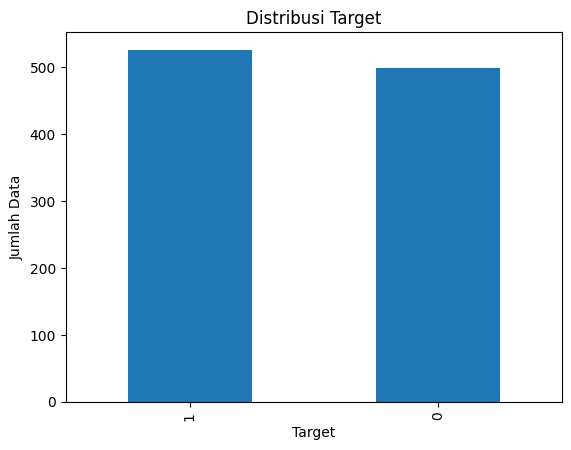

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("heart.csv")

df['target'].value_counts().plot(
    kind='bar'
)

plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Jumlah Data")
plt.show()

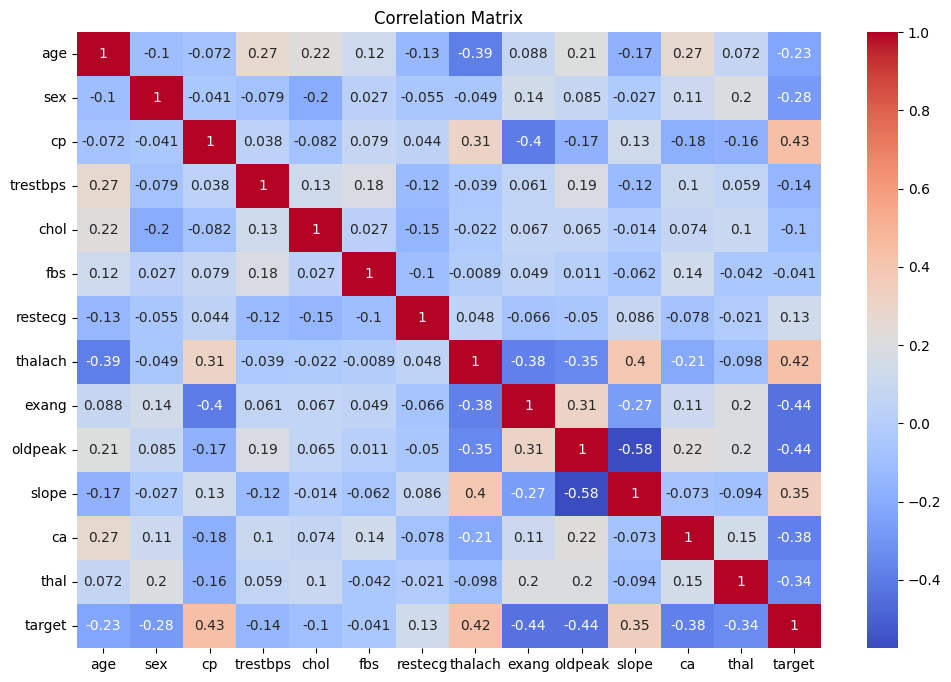

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

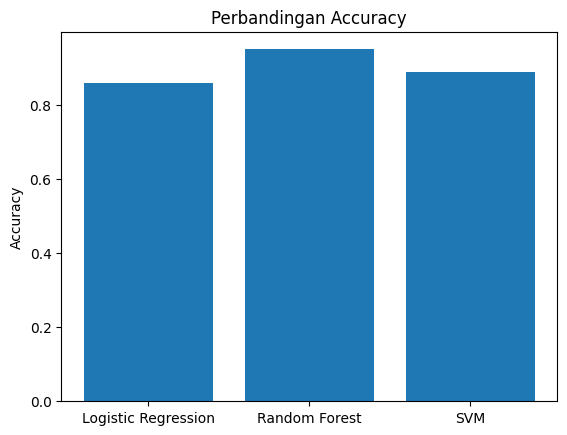

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Random Forest",
    "SVM"
]

accuracy = [
    0.86,
    0.95,
    0.89
]

plt.bar(models, accuracy)

plt.title("Perbandingan Accuracy")
plt.ylabel("Accuracy")

plt.show()

     Feature  Importance
2         cp    0.166320
7    thalach    0.128711
11        ca    0.109447
12      thal    0.099737
9    oldpeak    0.093087
0        age    0.086755
8      exang    0.072760
4       chol    0.070916
3   trestbps    0.070149
1        sex    0.037530
10     slope    0.031531
6    restecg    0.023953
5        fbs    0.009103


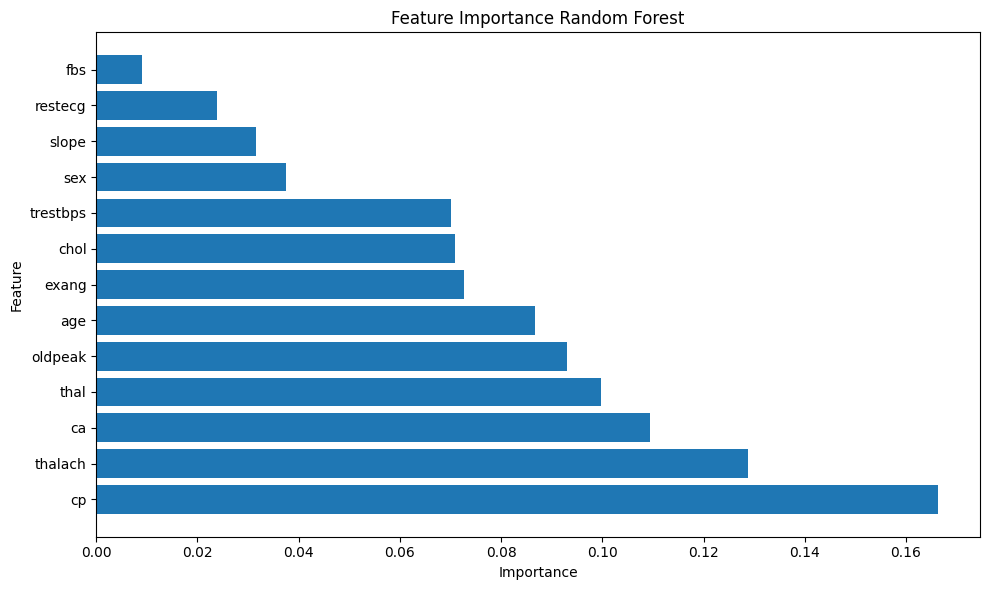

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Ambil nama fitur
feature_names = df.drop("target", axis=1).columns

# Train model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Feature importance
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance Random Forest")

plt.tight_layout()
plt.show()

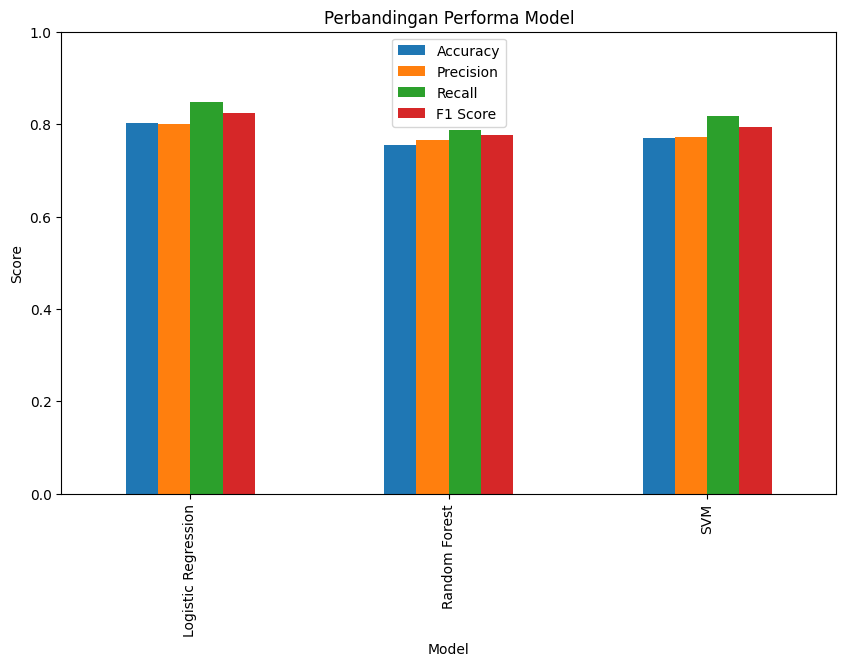

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = result_df.set_index("Model")

metrics.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Score")
plt.ylim(0,1)

plt.legend(loc="best")

plt.show()

In [ ]:
print(result_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.803279   0.800000  0.848485  0.823529
1        Random Forest  0.754098   0.764706  0.787879  0.776119
2                  SVM  0.770492   0.771429  0.818182  0.794118


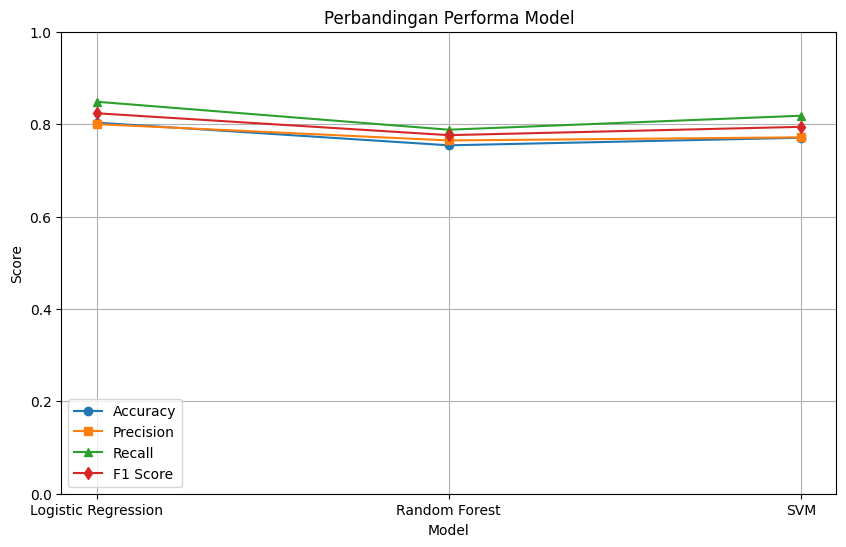

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    result_df["Model"],
    result_df["Accuracy"],
    marker='o',
    label='Accuracy'
)

plt.plot(
    result_df["Model"],
    result_df["Precision"],
    marker='s',
    label='Precision'
)

plt.plot(
    result_df["Model"],
    result_df["Recall"],
    marker='^',
    label='Recall'
)

plt.plot(
    result_df["Model"],
    result_df["F1 Score"],
    marker='d',
    label='F1 Score'
)

plt.title("Perbandingan Performa Model")
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.grid(True)
plt.legend()

plt.show()